# Load and plot DPR-DSA-03

Example walkthrough for the convening sample: find a **DPR-DSA-03** continuum
radio camera mosaic by product name under ``data/``, load the FITS image, and plot it.

`DPR-DSA-03` is a calibrated continuum mosaic (FITS, Jy/beam). **Download the sample into `data/`** (see `data/README.md`). Filenames should include the product
id, e.g. `mock_DPR-DSA-03.fits`.


> **Local copy:** `data/` holds DPR-DSA-07 spectral cubes instead of a DPR-DSA-03 mosaic, so this copy loads a DSA-07 cube and averages it over frequency to get a 2D image.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm
from astropy.wcs import WCS

from convening2026 import data_dir, find_product

# Product id used to locate the sample file by name under data/
PRODUCT = "DPR-DSA-07"

data_dir()


PosixPath('/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/science-symposium-2026-hackathon-materials/dsa/convening2026-release-2026.9.28/data')

In [2]:
fits_path = find_product(PRODUCT, pattern=f"**/*{PRODUCT}*.fits")
print(f"Using: {fits_path}")


Multiple matches for 'DPR-DSA-07'; using the first:
  - mock_DPR-DSA-07_zb_01.fits
  - mock_DPR-DSA-07_zb_02.fits
  - mock_DPR-DSA-07_zb_03.fits
  - mock_DPR-DSA-07_zb_04.fits
  - mock_DPR-DSA-07_zb_05.fits
  - mock_DPR-DSA-07_zb_06.fits
  - mock_DPR-DSA-07_zb_07.fits
  - mock_DPR-DSA-07_zb_08.fits
  - mock_DPR-DSA-07_zb_09.fits
  - mock_DPR-DSA-07_zb_10.fits
Using: /Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/science-symposium-2026-hackathon-materials/dsa/convening2026-release-2026.9.28/data/mock_DPR-DSA-07_zb_01.fits


In [3]:
with fits.open(fits_path) as hdul:
    hdul.info()
    primary = hdul[0]
    header = primary.header
    image = np.asarray(primary.data, dtype=float)
if image.ndim == 3:   # DPR-DSA-07 is a (freq, dec, ra) cube: average over frequency for a 2D image
    print(f"cube shape: {image.shape}; averaging over {image.shape[0]} channels")
    image = np.nanmean(image, axis=0)

print(f"shape: {image.shape}")
print(f"BUNIT: {header.get('BUNIT', 'n/a')}")
print(f"MOSAICID: {header.get('MOSAICID', 'n/a')}")
print(f"OBJECT: {header.get('OBJECT', 'n/a')}")


Filename: /Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/science-symposium-2026-hackathon-materials/dsa/convening2026-release-2026.9.28/data/mock_DPR-DSA-07_zb_01.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      68   (23, 23, 960)   float32   
  1  WEIGHT        1 ImageHDU        12   (23, 23, 960)   float32   


cube shape: (960, 23, 23); averaging over 960 channels
shape: (23, 23)
BUNIT: Jy/beam/channel
MOSAICID: mosaic-000001-v1
OBJECT: ZB-example-01


/var/folders/0t/mnkwbhz90sv50nypf2rcl8cr0000gp/T/ipykernel_94940/2024600544.py:8: RuntimeWarning: Mean of empty slice
  image = np.nanmean(image, axis=0)


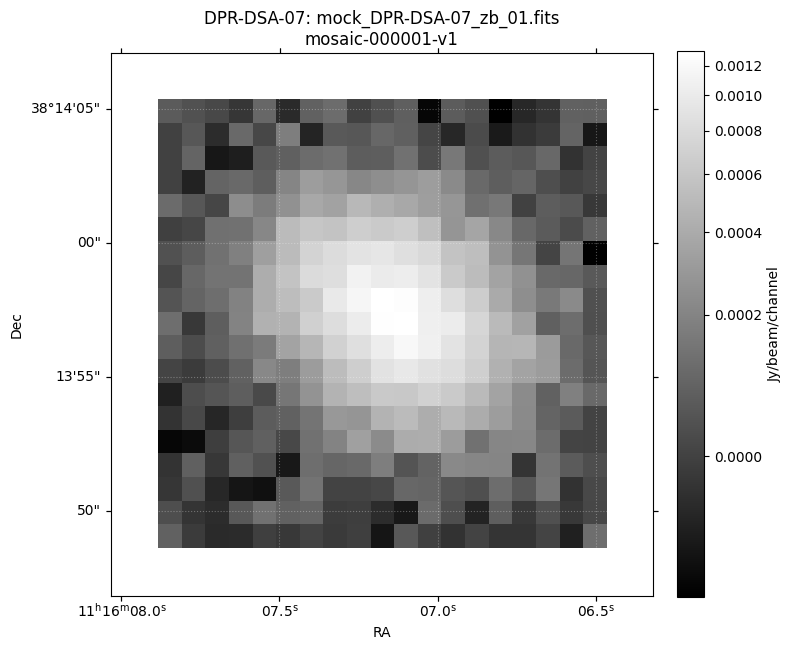

In [4]:
# Prefer a WCS axes when the header provides a celestial projection
wcs = None
try:
    candidate = WCS(header)
    if candidate.naxis >= 2 and candidate.has_celestial:
        wcs = candidate.celestial
except Exception as exc:
    print(f"WCS not available ({exc}); plotting in pixel coordinates.")

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(1, 1, 1, projection=wcs) if wcs is not None else fig.add_subplot(1, 1, 1)

finite = image[np.isfinite(image)]
norm = simple_norm(finite if finite.size else image, "asinh", percent=99.5)
im = ax.imshow(image, origin="lower", cmap="gray", norm=norm)

title = f"{PRODUCT}: {fits_path.name}"
if header.get("MOSAICID"):
    title += f"\n{header['MOSAICID']}"
ax.set_title(title)

if wcs is not None:
    ax.set_xlabel("RA")
    ax.set_ylabel("Dec")
    ax.coords.grid(True, color="white", alpha=0.3, linestyle=":")
else:
    ax.set_xlabel("x (pixel)")
    ax.set_ylabel("y (pixel)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label(header.get("BUNIT", "pixel value"))
plt.tight_layout()
plt.show()
